In [11]:
import pandas as pd
import numpy as np

In [12]:
monthly_demand = pd.read_csv(
    "../data/processed/monthly_demand_features.csv"
)

monthly_demand["MonthYear"] = pd.PeriodIndex(
    monthly_demand["MonthYear"],
    freq="M"
)

print("Shape:", monthly_demand.shape)
monthly_demand.head()

Shape: (79424, 15)


,StockCode,MonthYear,Monthly_Quantity,Monthly_Revenue,Monthly_Transactions,Average_Monthly_Price,Lag_1,Lag_2,Lag_3,Rolling_3_Month,Rolling_6_Month,Lag_1_Price,Price_Change_Pct,Price_Ratio,Log_Price_Ratio
0,10002,2009-12,215.0,185.30,20.0,0.977500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10002,2010-01,291.0,248.97,17.0,0.945294,215.0,NaN,NaN,NaN,NaN,0.977500,-3.294719,0.967053,-0.033502
2,10002,2010-02,257.0,220.07,15.0,0.958000,291.0,215.0,NaN,NaN,NaN,0.945294,1.344119,1.013441,0.013352
3,10002,2010-03,641.0,493.09,17.0,0.911111,257.0,291.0,215.0,254.333333,NaN,0.958000,-4.894456,0.951055,-0.050183
4,10002,2010-04,1132.0,843.73,24.0,0.924167,641.0,257.0,291.0,396.333333,NaN,0.911111,1.432927,1.014329,0.014228


In [13]:
monthly_demand = monthly_demand.sort_values(
    ["StockCode", "MonthYear"]
).reset_index(drop=True)

print(monthly_demand.head(15))

   StockCode MonthYear  Monthly_Quantity  Monthly_Revenue  \
0      10002   2009-12             215.0           185.30   
1      10002   2010-01             291.0           248.97   
2      10002   2010-02             257.0           220.07   
3      10002   2010-03             641.0           493.09   
4      10002   2010-04            1132.0           843.73   
5      10002   2010-05            1465.0          1157.49   
6      10002   2010-06             463.0           404.20   
7      10002   2010-07             512.0           416.49   
8      10002   2010-08             586.0           450.15   
9      10002   2010-09             240.0           213.72   
10     10002   2010-10            1045.0           793.97   
11     10002   2010-11             964.0           755.19   
12     10002   2010-12             251.0           234.41   
13     10002   2011-01             340.0           291.37   
14     10002   2011-02              52.0            45.76   

    Monthly_Transaction

In [14]:
monthly_demand["Next_Month_Quantity"] = (
    monthly_demand
    .groupby("StockCode")["Monthly_Quantity"]
    .shift(-1)
)

In [15]:
monthly_demand[
    [
        "StockCode",
        "MonthYear",
        "Monthly_Quantity",
        "Next_Month_Quantity"
    ]
].head(20)

,StockCode,MonthYear,Monthly_Quantity,Next_Month_Quantity
0,10002,2009-12,215.0,291.0
1,10002,2010-01,291.0,257.0
2,10002,2010-02,257.0,641.0
3,10002,2010-03,641.0,1132.0
4,10002,2010-04,1132.0,1465.0
5,10002,2010-05,1465.0,463.0
6,10002,2010-06,463.0,512.0
7,10002,2010-07,512.0,586.0
8,10002,2010-08,586.0,240.0
9,10002,2010-09,240.0,1045.0


In [16]:
print("Total rows:", len(monthly_demand))

print(
    "Rows with target:",
    monthly_demand["Next_Month_Quantity"].notna().sum()
)

print(
    "Rows without target:",
    monthly_demand["Next_Month_Quantity"].isna().sum()
)

Total rows: 79424
Rows with target: 74512
Rows without target: 4912


In [17]:
target_missing = monthly_demand[
    monthly_demand["Next_Month_Quantity"].isna()
]

print(
    "Products without next-month target:",
    target_missing["StockCode"].nunique()
)

print(
    target_missing["MonthYear"].value_counts().sort_index()
)

Products without next-month target: 4912
MonthYear
2009-12     144
2010-01      81
2010-02      59
2010-03     121
2010-04      65
2010-05      60
2010-06      65
2010-07      50
2010-08      78
2010-09      67
2010-10      82
2010-11     122
2010-12      94
2011-01      44
2011-02      38
2011-03      68
2011-04     105
2011-05      84
2011-06      71
2011-07      82
2011-08      76
2011-09      87
2011-10     159
2011-11     543
2011-12    2467
Freq: M, Name: count, dtype: int64


In [18]:
print(
    "Negative target values:",
    (monthly_demand["Next_Month_Quantity"] < 0).sum()
)

print(
    "Zero target values:",
    (monthly_demand["Next_Month_Quantity"] == 0).sum()
)

Negative target values: 0
Zero target values: 12443


In [19]:
monthly_demand["Next_Month_Quantity"].describe()

count    74512.000000
mean       138.436064
std        414.246503
min          0.000000
25%          2.000000
50%         20.000000
75%        107.000000
max      19249.000000
Name: Next_Month_Quantity, dtype: float64

In [21]:
monthly_demand["Next_Month_Quantity"] = (
    monthly_demand
    .groupby("StockCode")["Monthly_Quantity"]
    .shift(-1)
)

In [22]:
print("Total rows:", len(monthly_demand))

print(
    "Rows with target:",
    monthly_demand["Next_Month_Quantity"].notna().sum()
)

print(
    "Rows without target:",
    monthly_demand["Next_Month_Quantity"].isna().sum()
)

Total rows: 79424
Rows with target: 74512
Rows without target: 4912


In [23]:
monthly_demand[
    [
        "StockCode",
        "MonthYear",
        "Monthly_Quantity",
        "Next_Month_Quantity"
    ]
].head(20)

,StockCode,MonthYear,Monthly_Quantity,Next_Month_Quantity
0,10002,2009-12,215.0,291.0
1,10002,2010-01,291.0,257.0
2,10002,2010-02,257.0,641.0
3,10002,2010-03,641.0,1132.0
4,10002,2010-04,1132.0,1465.0
5,10002,2010-05,1465.0,463.0
6,10002,2010-06,463.0,512.0
7,10002,2010-07,512.0,586.0
8,10002,2010-08,586.0,240.0
9,10002,2010-09,240.0,1045.0


In [24]:
print("Negative targets:",
      (monthly_demand["Next_Month_Quantity"] < 0).sum())

print("Zero targets:",
      (monthly_demand["Next_Month_Quantity"] == 0).sum())

print(
    monthly_demand["Next_Month_Quantity"].describe()
)

Negative targets: 0
Zero targets: 12443
count    74512.000000
mean       138.436064
std        414.246503
min          0.000000
25%          2.000000
50%         20.000000
75%        107.000000
max      19249.000000
Name: Next_Month_Quantity, dtype: float64


In [25]:
monthly_demand["Month"] = monthly_demand["MonthYear"].dt.month

monthly_demand["Quarter"] = monthly_demand["MonthYear"].dt.quarter

In [26]:
monthly_demand[
    ["StockCode", "MonthYear", "Month", "Quarter"]
].head(15)

,StockCode,MonthYear,Month,Quarter
0,10002,2009-12,12,4
1,10002,2010-01,1,1
2,10002,2010-02,2,1
3,10002,2010-03,3,1
4,10002,2010-04,4,2
5,10002,2010-05,5,2
6,10002,2010-06,6,2
7,10002,2010-07,7,3
8,10002,2010-08,8,3
9,10002,2010-09,9,3


In [27]:
feature_columns = [
    "Monthly_Quantity",
    "Lag_1",
    "Lag_2",
    "Lag_3",
    "Rolling_3_Month",
    "Rolling_6_Month",
    "Monthly_Transactions",
    "Average_Monthly_Price",
    "Lag_1_Price",
    "Price_Change_Pct",
    "Log_Price_Ratio",
    "Month",
    "Quarter"
]

In [28]:
target_column = "Next_Month_Quantity"

In [29]:
model_data = monthly_demand[
    feature_columns +
    [target_column, "StockCode", "MonthYear"]
].copy()

print("Model data shape:", model_data.shape)

Model data shape: (79424, 16)


In [30]:
model_data.isna().sum().sort_values(ascending=False)

Rolling_6_Month          26638
Price_Change_Pct         23071
Log_Price_Ratio          23071
Lag_1_Price              17355
Rolling_3_Month          14101
Lag_3                    14101
Average_Monthly_Price    12443
Lag_2                     9565
Lag_1                     4912
Next_Month_Quantity       4912
Monthly_Transactions         0
Monthly_Quantity             0
Month                        0
Quarter                      0
StockCode                    0
MonthYear                    0
dtype: int64

In [31]:
model_data = model_data.dropna(
    subset=["Next_Month_Quantity"]
).copy()

print("Rows after removing missing targets:", len(model_data))

Rows after removing missing targets: 74512


In [32]:
model_data[feature_columns].isna().sum()

Monthly_Quantity             0
Lag_1                     4653
Lag_2                     9189
Lag_3                    13545
Rolling_3_Month          13545
Rolling_6_Month          25671
Monthly_Transactions         0
Average_Monthly_Price    12443
Lag_1_Price              16382
Price_Change_Pct         22098
Log_Price_Ratio          22098
Month                        0
Quarter                      0
dtype: int64

In [33]:
model_data_complete = model_data.dropna(
    subset=feature_columns
).copy()

print("Rows before removing feature missing values:", len(model_data))
print("Rows after removing feature missing values:", len(model_data_complete))

print(
    "Products remaining:",
    model_data_complete["StockCode"].nunique()
)

Rows before removing feature missing values: 74512
Rows after removing feature missing values: 36265
Products remaining: 3514


In [34]:
print(
    model_data_complete[feature_columns]
    .isna()
    .sum()
)

Monthly_Quantity         0
Lag_1                    0
Lag_2                    0
Lag_3                    0
Rolling_3_Month          0
Rolling_6_Month          0
Monthly_Transactions     0
Average_Monthly_Price    0
Lag_1_Price              0
Price_Change_Pct         0
Log_Price_Ratio          0
Month                    0
Quarter                  0
dtype: int64


In [35]:
print(
    "Missing target:",
    model_data_complete["Next_Month_Quantity"].isna().sum()
)

Missing target: 0


In [36]:
print(model_data_complete.shape)

model_data_complete[
    [
        "StockCode",
        "MonthYear",
        "Monthly_Quantity",
        "Lag_1",
        "Lag_2",
        "Lag_3",
        "Rolling_3_Month",
        "Rolling_6_Month",
        "Average_Monthly_Price",
        "Next_Month_Quantity"
    ]
].head(15)

(36265, 16)


,StockCode,MonthYear,Monthly_Quantity,Lag_1,Lag_2,Lag_3,Rolling_3_Month,Rolling_6_Month,Average_Monthly_Price,Next_Month_Quantity
6,10002,2010-06,463.0,1465.0,1132.0,641.0,1079.333333,666.833333,0.999730,512.0
7,10002,2010-07,512.0,463.0,1465.0,1132.0,1020.000000,708.166667,0.969615,586.0
8,10002,2010-08,586.0,512.0,463.0,1465.0,813.333333,745.000000,1.014783,240.0
9,10002,2010-09,240.0,586.0,512.0,463.0,520.333333,799.833333,0.971500,1045.0
10,10002,2010-10,1045.0,240.0,586.0,512.0,446.000000,733.000000,0.873913,964.0
11,10002,2010-11,964.0,1045.0,240.0,586.0,623.666667,718.500000,0.926410,251.0
12,10002,2010-12,251.0,964.0,1045.0,240.0,749.666667,635.000000,1.201000,340.0
13,10002,2011-01,340.0,251.0,964.0,1045.0,753.333333,599.666667,0.962857,52.0
14,10002,2011-02,52.0,340.0,251.0,964.0,518.333333,571.000000,1.072857,28.0
15,10002,2011-03,28.0,52.0,340.0,251.0,214.333333,482.000000,1.142500,189.0


In [37]:
print("Start date:", model_data_complete["MonthYear"].min())
print("End date:", model_data_complete["MonthYear"].max())

print(
    model_data_complete["MonthYear"]
    .sort_values()
    .unique()
)

Start date: 2010-06
End date: 2011-11
<PeriodArray>
['2010-06', '2010-07', '2010-08', '2010-09', '2010-10', '2010-11', '2010-12',
 '2011-01', '2011-02', '2011-03', '2011-04', '2011-05', '2011-06', '2011-07',
 '2011-08', '2011-09', '2011-10', '2011-11']
Length: 18, dtype: period[M]


In [38]:
train_data = model_data_complete[
    model_data_complete["MonthYear"] <= pd.Period("2011-06", freq="M")
].copy()

test_data = model_data_complete[
    model_data_complete["MonthYear"] >= pd.Period("2011-07", freq="M")
].copy()

In [39]:
print("Training shape:", train_data.shape)
print("Testing shape:", test_data.shape)

print(
    "\nTraining period:",
    train_data["MonthYear"].min(),
    "to",
    train_data["MonthYear"].max()
)

print(
    "Testing period:",
    test_data["MonthYear"].min(),
    "to",
    test_data["MonthYear"].max()
)

Training shape: (26182, 16)
Testing shape: (10083, 16)

Training period: 2010-06 to 2011-06
Testing period: 2011-07 to 2011-11


In [40]:
X_train = train_data[feature_columns]
y_train = train_data["Next_Month_Quantity"]

X_test = test_data[feature_columns]
y_test = test_data["Next_Month_Quantity"]

In [41]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (26182, 13)
y_train: (26182,)
X_test: (10083, 13)
y_test: (10083,)


In [42]:
print("Training maximum month:",
      train_data["MonthYear"].max())

print("Testing minimum month:",
      test_data["MonthYear"].min())

Training maximum month: 2011-06
Testing minimum month: 2011-07


In [43]:
y_pred_baseline = X_test["Monthly_Quantity"]

In [44]:
from sklearn.metrics import mean_absolute_error

baseline_mae = mean_absolute_error(
    y_test,
    y_pred_baseline
)

print("Baseline MAE:", baseline_mae)

Baseline MAE: 136.14142616284835


In [45]:
from sklearn.metrics import mean_squared_error
import numpy as np

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_baseline
    )
)

print("Baseline RMSE:", baseline_rmse)

Baseline RMSE: 361.77882727589173


In [46]:
non_zero = y_test != 0

baseline_mape = np.mean(
    np.abs(
        (y_test[non_zero] - y_pred_baseline[non_zero])
        / y_test[non_zero]
    )
) * 100

print("Baseline MAPE:", baseline_mape)

Baseline MAPE: 263.86291983461547


In [47]:
baseline_results = pd.DataFrame({
    "Model": ["Naive Baseline"],
    "MAE": [baseline_mae],
    "RMSE": [baseline_rmse],
    "MAPE": [baseline_mape]
})

baseline_results

,Model,MAE,RMSE,MAPE
0,Naive Baseline,136.141426,361.778827,263.86292


In [48]:
from sklearn.linear_model import LinearRegression

In [49]:
lr_model = LinearRegression()

lr_model.fit(
    X_train,
    y_train
)

LinearRegression()

In [50]:
y_pred_lr = lr_model.predict(X_test)

In [51]:
lr_mae = mean_absolute_error(
    y_test,
    y_pred_lr
)

lr_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_lr
    )
)

print("Linear Regression MAE:", lr_mae)
print("Linear Regression RMSE:", lr_rmse)

Linear Regression MAE: 125.73221377661254
Linear Regression RMSE: 307.49429235811095


In [52]:
non_zero = y_test != 0

lr_mape = np.mean(
    np.abs(
        (y_test[non_zero] - y_pred_lr[non_zero])
        / y_test[non_zero]
    )
) * 100

print("Linear Regression MAPE:", lr_mape)

Linear Regression MAPE: 390.2792552098947


In [53]:
lr_results = pd.DataFrame({
    "Model": ["Linear Regression"],
    "MAE": [lr_mae],
    "RMSE": [lr_rmse],
    "MAPE": [lr_mape]
})

lr_results

,Model,MAE,RMSE,MAPE
0,Linear Regression,125.732214,307.494292,390.279255


In [54]:
from sklearn.ensemble import RandomForestRegressor

In [55]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

RandomForestRegressor(max_depth=15, min_samples_leaf=2, n_jobs=-1,
                      random_state=42)

In [56]:
y_pred_rf = rf_model.predict(X_test)

In [57]:
rf_mae = mean_absolute_error(
    y_test,
    y_pred_rf
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_rf
    )
)

print("Random Forest MAE:", rf_mae)
print("Random Forest RMSE:", rf_rmse)

Random Forest MAE: 109.9483136494592
Random Forest RMSE: 271.3865577543771


In [58]:
non_zero = y_test != 0

rf_mape = np.mean(
    np.abs(
        (y_test[non_zero] - y_pred_rf[non_zero])
        / y_test[non_zero]
    )
) * 100

print("Random Forest MAPE:", rf_mape)

Random Forest MAPE: 356.2305595290376


In [59]:
rf_results = pd.DataFrame({
    "Model": ["Random Forest"],
    "MAE": [rf_mae],
    "RMSE": [rf_rmse],
    "MAPE": [rf_mape]
})

rf_results

,Model,MAE,RMSE,MAPE
0,Random Forest,109.948314,271.386558,356.23056


In [60]:
model_results = pd.concat(
    [
        baseline_results,
        lr_results,
        rf_results
    ],
    ignore_index=True
)

model_results

,Model,MAE,RMSE,MAPE
0,Naive Baseline,136.141426,361.778827,263.862920
1,Linear Regression,125.732214,307.494292,390.279255
2,Random Forest,109.948314,271.386558,356.230560


In [61]:
from sklearn.ensemble import GradientBoostingRegressor

In [62]:
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5,
    min_samples_leaf=5,
    random_state=42
)

gb_model.fit(
    X_train,
    y_train
)

GradientBoostingRegressor(learning_rate=0.05, max_depth=5, min_samples_leaf=5,
                          random_state=42)

In [63]:
y_pred_gb = gb_model.predict(X_test)

In [64]:
gb_mae = mean_absolute_error(
    y_test,
    y_pred_gb
)

gb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_gb
    )
)

print("Gradient Boosting MAE:", gb_mae)
print("Gradient Boosting RMSE:", gb_rmse)

Gradient Boosting MAE: 109.5356224532823
Gradient Boosting RMSE: 269.2493995718468


In [65]:
non_zero = y_test != 0

gb_mape = np.mean(
    np.abs(
        (y_test[non_zero] - y_pred_gb[non_zero])
        / y_test[non_zero]
    )
) * 100

print("Gradient Boosting MAPE:", gb_mape)

Gradient Boosting MAPE: 389.19798235831024


In [66]:
gb_results = pd.DataFrame({
    "Model": ["Gradient Boosting"],
    "MAE": [gb_mae],
    "RMSE": [gb_rmse],
    "MAPE": [gb_mape]
})

gb_results

,Model,MAE,RMSE,MAPE
0,Gradient Boosting,109.535622,269.2494,389.197982


In [67]:
model_results = pd.concat(
    [
        baseline_results,
        lr_results,
        rf_results,
        gb_results
    ],
    ignore_index=True
)

model_results

,Model,MAE,RMSE,MAPE
0,Naive Baseline,136.141426,361.778827,263.862920
1,Linear Regression,125.732214,307.494292,390.279255
2,Random Forest,109.948314,271.386558,356.230560
3,Gradient Boosting,109.535622,269.249400,389.197982


In [68]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": gb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance

,Feature,Importance
0,Monthly_Quantity,0.638642
5,Rolling_6_Month,0.101199
11,Month,0.054611
4,Rolling_3_Month,0.037660
2,Lag_2,0.033593
1,Lag_1,0.030418
6,Monthly_Transactions,0.026597
3,Lag_3,0.023301
7,Average_Monthly_Price,0.017345
8,Lag_1_Price,0.016603


In [69]:
feature_importance.head(15)

,Feature,Importance
0,Monthly_Quantity,0.638642
5,Rolling_6_Month,0.101199
11,Month,0.054611
4,Rolling_3_Month,0.037660
2,Lag_2,0.033593
1,Lag_1,0.030418
6,Monthly_Transactions,0.026597
3,Lag_3,0.023301
7,Average_Monthly_Price,0.017345
8,Lag_1_Price,0.016603


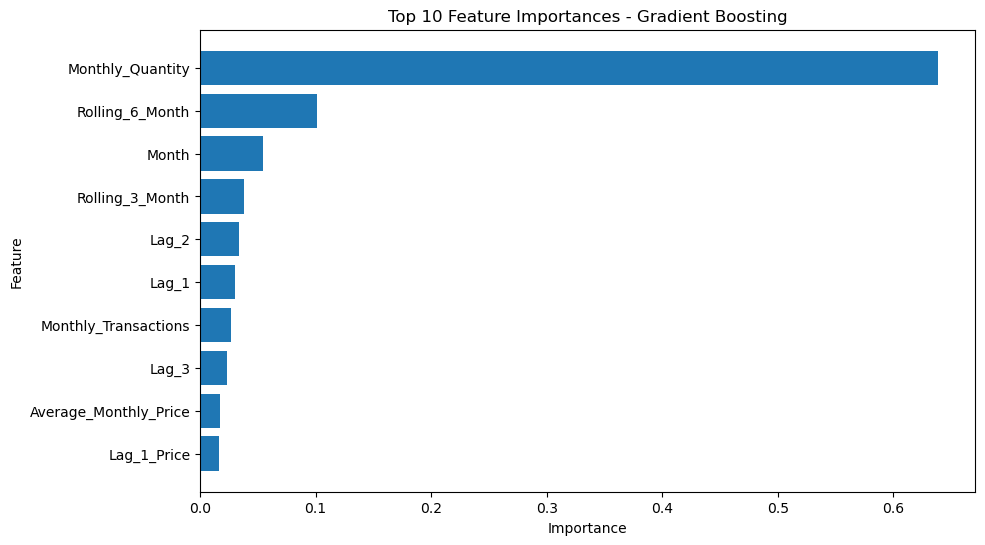

In [70]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

top_features = feature_importance.head(10).sort_values(
    "Importance"
)

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances - Gradient Boosting")
plt.show()

In [71]:
rf_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

rf_importance = rf_importance.sort_values(
    "Importance",
    ascending=False
)

rf_importance.head(15)

,Feature,Importance
0,Monthly_Quantity,0.558139
5,Rolling_6_Month,0.116300
4,Rolling_3_Month,0.056593
3,Lag_3,0.040807
6,Monthly_Transactions,0.035264
11,Month,0.035013
2,Lag_2,0.034652
1,Lag_1,0.032502
7,Average_Monthly_Price,0.031354
8,Lag_1_Price,0.020880


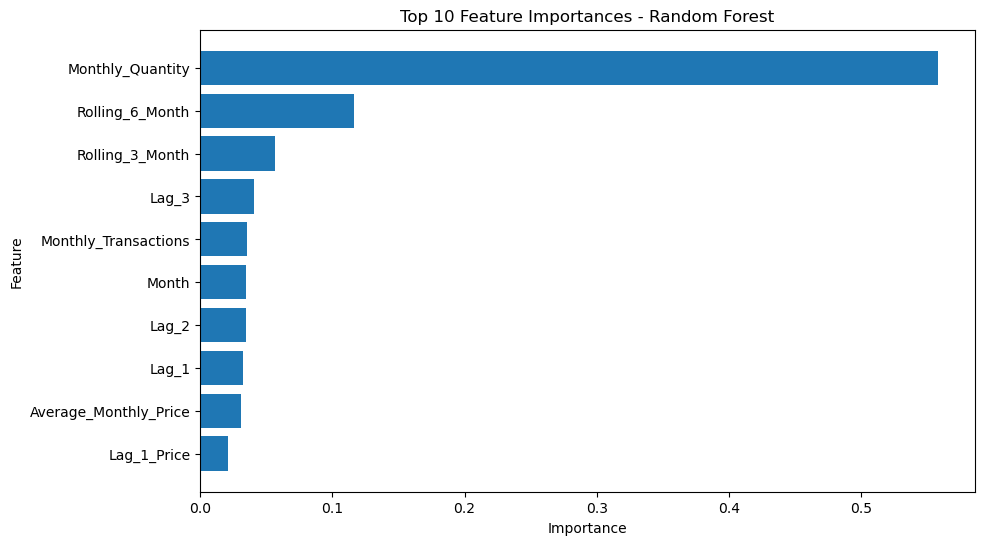

In [72]:
plt.figure(figsize=(10, 6))

top_rf = rf_importance.head(10).sort_values(
    "Importance"
)

plt.barh(
    top_rf["Feature"],
    top_rf["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances - Random Forest")
plt.show()

In [73]:
evaluation = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_gb
})

evaluation["Error"] = (
    evaluation["Actual"] - evaluation["Predicted"]
)

evaluation["Absolute_Error"] = (
    evaluation["Error"].abs()
)

evaluation.head(10)

,Actual,Predicted,Error,Absolute_Error
0,60.0,80.466519,-20.466519,20.466519
1,60.0,81.235352,-21.235352,21.235352
2,6.0,87.035959,-81.035959,81.035959
3,91.0,66.753265,24.246735,24.246735
4,10.0,62.080875,-52.080875,52.080875
5,10.0,61.843447,-51.843447,51.843447
6,49.0,49.189331,-0.189331,0.189331
7,6.0,56.451350,-50.451350,50.451350
8,85.0,138.722496,-53.722496,53.722496
9,210.0,93.721268,116.278732,116.278732


In [74]:
evaluation.describe()

,Actual,Predicted,Error,Absolute_Error
count,10083.000000,10083.000000,10083.000000,10083.000000
mean,189.539919,194.988347,-5.448429,109.535622
std,438.770234,364.156647,269.207618,245.973956
min,0.000000,13.844499,-5803.657483,0.008488
25%,12.000000,39.401558,-54.304591,19.914512
50%,49.000000,78.593062,-22.551113,39.954591
75%,179.000000,197.351602,6.162148,100.492488
max,12452.000000,7192.657483,6082.633839,6082.633839


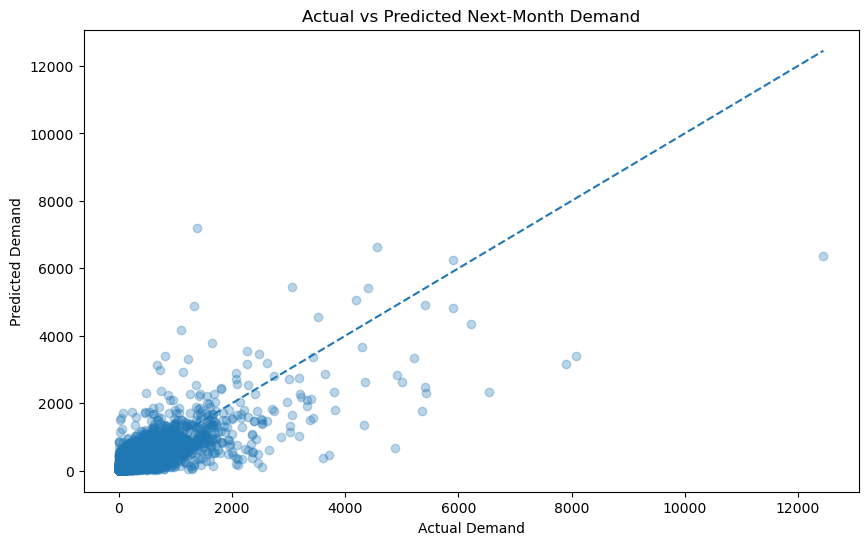

In [77]:
plt.figure(figsize=(10, 6))

plt.scatter(
    evaluation["Actual"],
    evaluation["Predicted"],
    alpha=0.3
)

max_value = max(
    evaluation["Actual"].max(),
    evaluation["Predicted"].max()
)

plt.plot(
    [0, max_value],
    [0, max_value],
    linestyle="--"
)

plt.xlabel("Actual Demand")
plt.ylabel("Predicted Demand")
plt.title("Actual vs Predicted Next-Month Demand")
plt.show()

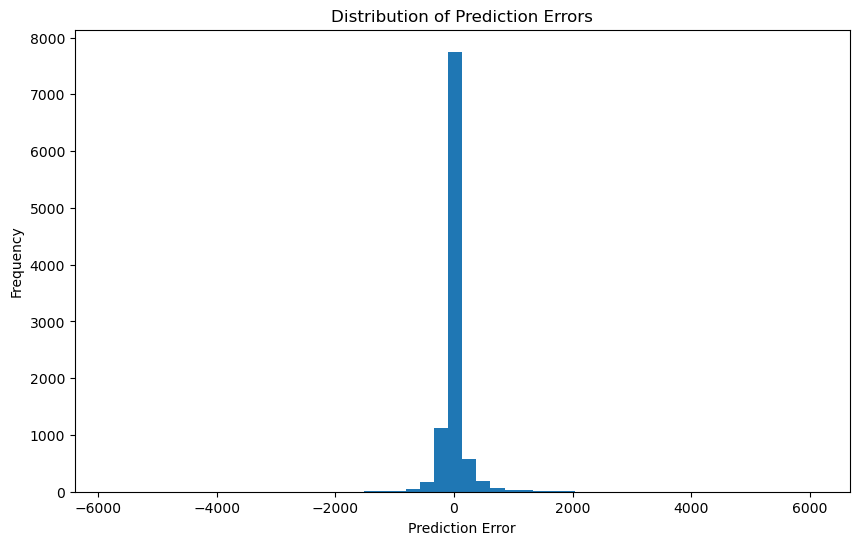

In [78]:
plt.figure(figsize=(10, 6))

plt.hist(
    evaluation["Error"],
    bins=50
)

plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Distribution of Prediction Errors")
plt.show()

In [79]:
evaluation.sort_values(
    "Absolute_Error",
    ascending=False
).head(15)

,Actual,Predicted,Error,Absolute_Error
3799,12452.0,6369.366161,6082.633839,6082.633839
773,1389.0,7192.657483,-5803.657483,5803.657483
3373,7898.0,3166.199108,4731.800892,4731.800892
8300,8084.0,3408.199469,4675.800531,4675.800531
8754,6545.0,2340.566962,4204.433038,4204.433038
772,4872.0,674.178400,4197.821600,4197.821600
5263,5365.0,1759.990301,3605.009699,3605.009699
8758,1330.0,4872.749625,-3542.749625,3542.749625
121,3606.0,362.565824,3243.434176,3243.434176
6809,3710.0,469.033894,3240.966106,3240.966106


In [80]:
model_results.sort_values(
    "MAE"
).reset_index(drop=True)

,Model,MAE,RMSE,MAPE
0,Gradient Boosting,109.535622,269.249400,389.197982
1,Random Forest,109.948314,271.386558,356.230560
2,Linear Regression,125.732214,307.494292,390.279255
3,Naive Baseline,136.141426,361.778827,263.862920


In [81]:
evaluation = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_gb
})

evaluation["Error"] = (
    evaluation["Actual"] - evaluation["Predicted"]
)

evaluation["Absolute_Error"] = (
    evaluation["Error"].abs()
)

evaluation.head(10)

,Actual,Predicted,Error,Absolute_Error
0,60.0,80.466519,-20.466519,20.466519
1,60.0,81.235352,-21.235352,21.235352
2,6.0,87.035959,-81.035959,81.035959
3,91.0,66.753265,24.246735,24.246735
4,10.0,62.080875,-52.080875,52.080875
5,10.0,61.843447,-51.843447,51.843447
6,49.0,49.189331,-0.189331,0.189331
7,6.0,56.451350,-50.451350,50.451350
8,85.0,138.722496,-53.722496,53.722496
9,210.0,93.721268,116.278732,116.278732


In [82]:
evaluation.describe()

,Actual,Predicted,Error,Absolute_Error
count,10083.000000,10083.000000,10083.000000,10083.000000
mean,189.539919,194.988347,-5.448429,109.535622
std,438.770234,364.156647,269.207618,245.973956
min,0.000000,13.844499,-5803.657483,0.008488
25%,12.000000,39.401558,-54.304591,19.914512
50%,49.000000,78.593062,-22.551113,39.954591
75%,179.000000,197.351602,6.162148,100.492488
max,12452.000000,7192.657483,6082.633839,6082.633839


In [83]:
evaluation.sort_values(
    "Absolute_Error",
    ascending=False
).head(15)

,Actual,Predicted,Error,Absolute_Error
3799,12452.0,6369.366161,6082.633839,6082.633839
773,1389.0,7192.657483,-5803.657483,5803.657483
3373,7898.0,3166.199108,4731.800892,4731.800892
8300,8084.0,3408.199469,4675.800531,4675.800531
8754,6545.0,2340.566962,4204.433038,4204.433038
772,4872.0,674.178400,4197.821600,4197.821600
5263,5365.0,1759.990301,3605.009699,3605.009699
8758,1330.0,4872.749625,-3542.749625,3542.749625
121,3606.0,362.565824,3243.434176,3243.434176
6809,3710.0,469.033894,3240.966106,3240.966106


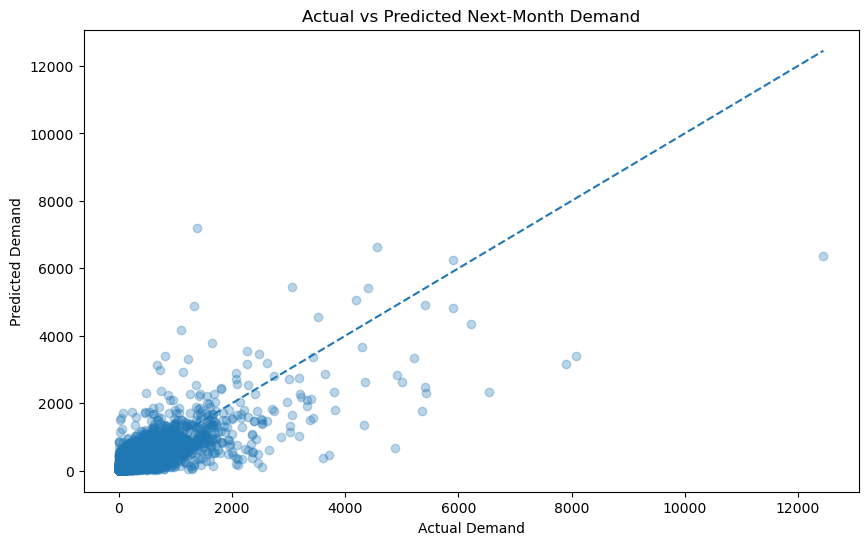

In [84]:
plt.figure(figsize=(10, 6))

plt.scatter(
    evaluation["Actual"],
    evaluation["Predicted"],
    alpha=0.3
)

max_value = max(
    evaluation["Actual"].max(),
    evaluation["Predicted"].max()
)

plt.plot(
    [0, max_value],
    [0, max_value],
    linestyle="--"
)

plt.xlabel("Actual Demand")
plt.ylabel("Predicted Demand")
plt.title("Actual vs Predicted Next-Month Demand")
plt.show()

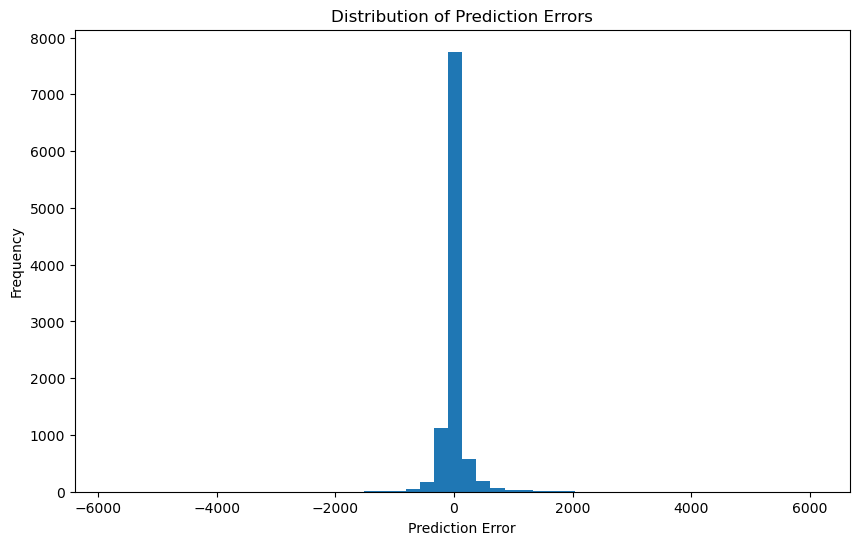

In [85]:
plt.figure(figsize=(10, 6))

plt.hist(
    evaluation["Error"],
    bins=50
)

plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Distribution of Prediction Errors")
plt.show()

In [86]:
evaluation["Demand_Level"] = pd.cut(
    evaluation["Actual"],
    bins=[-1, 10, 50, 100, 500, 1000, 5000, np.inf],
    labels=[
        "0-10",
        "11-50",
        "51-100",
        "101-500",
        "501-1000",
        "1001-5000",
        "5000+"
    ]
)

evaluation.head()

,Actual,Predicted,Error,Absolute_Error,Demand_Level
0,60.0,80.466519,-20.466519,20.466519,51-100
1,60.0,81.235352,-21.235352,21.235352,51-100
2,6.0,87.035959,-81.035959,81.035959,0-10
3,91.0,66.753265,24.246735,24.246735,51-100
4,10.0,62.080875,-52.080875,52.080875,0-10


In [87]:
error_by_level = evaluation.groupby(
    "Demand_Level",
    observed=False
).agg(
    Count=("Actual", "count"),
    MAE=("Absolute_Error", "mean"),
    Mean_Actual=("Actual", "mean"),
    Mean_Predicted=("Predicted", "mean")
).reset_index()

error_by_level

,Demand_Level,Count,MAE,Mean_Actual,Mean_Predicted
0,0-10,2414,38.648962,3.854184,42.503146
1,11-50,2701,45.929645,26.935579,71.453794
2,51-100,1327,59.335847,73.825923,119.092218
3,101-500,2638,118.217677,230.744503,246.324240
4,501-1000,645,316.439337,699.232558,595.622016
5,1001-5000,345,739.295262,1700.205797,1247.218238
6,5000+,13,2871.998299,6525.153846,3704.846580


In [88]:
error_by_level["Mean_Error"] = (
    evaluation.groupby(
        "Demand_Level",
        observed=False
    )["Error"].mean().values
)

error_by_level

,Demand_Level,Count,MAE,Mean_Actual,Mean_Predicted,Mean_Error
0,0-10,2414,38.648962,3.854184,42.503146,-38.648962
1,11-50,2701,45.929645,26.935579,71.453794,-44.518214
2,51-100,1327,59.335847,73.825923,119.092218,-45.266295
3,101-500,2638,118.217677,230.744503,246.324240,-15.579736
4,501-1000,645,316.439337,699.232558,595.622016,103.610542
5,1001-5000,345,739.295262,1700.205797,1247.218238,452.987559
6,5000+,13,2871.998299,6525.153846,3704.846580,2820.307266


In [89]:
zero_actual = evaluation["Actual"] == 0

print("Actual zero-demand rows:", zero_actual.sum())

print(
    "Average prediction when actual demand is zero:",
    evaluation.loc[zero_actual, "Predicted"].mean()
)

print(
    "Minimum prediction:",
    evaluation["Predicted"].min()
)

Actual zero-demand rows: 333
Average prediction when actual demand is zero: 45.66975917990031
Minimum prediction: 13.844499098171848


In [90]:
high_demand = evaluation["Actual"] > 1000

print("High-demand rows:", high_demand.sum())

print(
    "High-demand MAE:",
    evaluation.loc[high_demand, "Absolute_Error"].mean()
)

print(
    "High-demand actual mean:",
    evaluation.loc[high_demand, "Actual"].mean()
)

print(
    "High-demand predicted mean:",
    evaluation.loc[high_demand, "Predicted"].mean()
)

High-demand rows: 358
High-demand MAE: 816.7397856459844
High-demand actual mean: 1875.4134078212292
High-demand predicted mean: 1336.4617250577871


In [91]:
model_data_complete["Target_Month"] = (
    model_data_complete["Month"] % 12
) + 1

model_data_complete["Target_Quarter"] = (
    (model_data_complete["Target_Month"] - 1) // 3
) + 1

In [92]:
model_data_complete[
    [
        "Month",
        "Quarter",
        "Target_Month",
        "Target_Quarter",
        "Next_Month_Quantity"
    ]
].head(15)

,Month,Quarter,Target_Month,Target_Quarter,Next_Month_Quantity
6,6,2,7,3,512.0
7,7,3,8,3,586.0
8,8,3,9,3,240.0
9,9,3,10,4,1045.0
10,10,4,11,4,964.0
11,11,4,12,4,251.0
12,12,4,1,1,340.0
13,1,1,2,1,52.0
14,2,1,3,1,28.0
15,3,1,4,2,189.0


In [93]:
feature_columns

['Monthly_Quantity',
 'Lag_1',
 'Lag_2',
 'Lag_3',
 'Rolling_3_Month',
 'Rolling_6_Month',
 'Monthly_Transactions',
 'Average_Monthly_Price',
 'Lag_1_Price',
 'Price_Change_Pct',
 'Log_Price_Ratio',
 'Month',
 'Quarter']

In [94]:
corrected_features = [
    "Monthly_Quantity",
    "Lag_1",
    "Lag_2",
    "Lag_3",
    "Rolling_3_Month",
    "Rolling_6_Month",
    "Monthly_Transactions",
    "Average_Monthly_Price",
    "Lag_1_Price",
    "Price_Change_Pct",
    "Log_Price_Ratio",
    "Target_Month",
    "Target_Quarter"
]

In [95]:
model_data_corrected = model_data_complete[
    corrected_features + [
        "Next_Month_Quantity",
        "StockCode",
        "MonthYear"
    ]
].copy()

In [97]:
model_data_corrected = model_data_corrected.dropna(
    subset=corrected_features + ["Next_Month_Quantity"]
).copy()

print("Corrected modeling data shape:", model_data_corrected.shape)

Corrected modeling data shape: (36265, 16)


In [98]:
train_corrected = model_data_corrected[
    model_data_corrected["MonthYear"] <= pd.Period("2011-06", freq="M")
].copy()

test_corrected = model_data_corrected[
    model_data_corrected["MonthYear"] >= pd.Period("2011-07", freq="M")
].copy()

print("Training:", train_corrected.shape)
print("Testing:", test_corrected.shape)

Training: (26182, 16)
Testing: (10083, 16)


In [99]:
X_train_corrected = train_corrected[corrected_features]
y_train_corrected = train_corrected["Next_Month_Quantity"]

X_test_corrected = test_corrected[corrected_features]
y_test_corrected = test_corrected["Next_Month_Quantity"]

print("X_train:", X_train_corrected.shape)
print("X_test:", X_test_corrected.shape)

X_train: (26182, 13)
X_test: (10083, 13)


In [100]:
gb_corrected = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5,
    min_samples_leaf=5,
    random_state=42
)

gb_corrected.fit(
    X_train_corrected,
    y_train_corrected
)

GradientBoostingRegressor(learning_rate=0.05, max_depth=5, min_samples_leaf=5,
                          random_state=42)

In [101]:
y_pred_corrected = gb_corrected.predict(
    X_test_corrected
)

In [102]:
corrected_mae = mean_absolute_error(
    y_test_corrected,
    y_pred_corrected
)

corrected_rmse = np.sqrt(
    mean_squared_error(
        y_test_corrected,
        y_pred_corrected
    )
)

print("Corrected Gradient Boosting MAE:", corrected_mae)
print("Corrected Gradient Boosting RMSE:", corrected_rmse)

Corrected Gradient Boosting MAE: 108.56746604496233
Corrected Gradient Boosting RMSE: 265.048677150999


In [103]:
evaluation_corrected = pd.DataFrame({
    "Actual": y_test_corrected.values,
    "Predicted": y_pred_corrected
})

evaluation_corrected["Error"] = (
    evaluation_corrected["Actual"]
    - evaluation_corrected["Predicted"]
)

evaluation_corrected["Absolute_Error"] = (
    evaluation_corrected["Error"].abs()
)

evaluation_corrected["Demand_Level"] = pd.cut(
    evaluation_corrected["Actual"],
    bins=[-1, 10, 50, 100, 500, 1000, 5000, np.inf],
    labels=[
        "0-10",
        "11-50",
        "51-100",
        "101-500",
        "501-1000",
        "1001-5000",
        "5000+"
    ]
)

error_by_level_corrected = (
    evaluation_corrected
    .groupby("Demand_Level", observed=False)
    .agg(
        Count=("Actual", "count"),
        MAE=("Absolute_Error", "mean"),
        Mean_Actual=("Actual", "mean"),
        Mean_Predicted=("Predicted", "mean"),
        Mean_Error=("Error", "mean")
    )
    .reset_index()
)

error_by_level_corrected

,Demand_Level,Count,MAE,Mean_Actual,Mean_Predicted,Mean_Error
0,0-10,2414,38.564970,3.854184,42.419154,-38.564970
1,11-50,2701,46.245068,26.935579,71.904969,-44.969390
2,51-100,1327,58.426950,73.825923,119.123941,-45.298017
3,101-500,2638,117.237539,230.744503,244.463259,-13.718756
4,501-1000,645,316.108698,699.232558,591.293350,107.939208
5,1001-5000,345,720.870764,1700.205797,1251.763389,448.442409
6,5000+,13,2868.175329,6525.153846,3803.599279,2721.554568


In [104]:
print("Actual zero-demand rows:",
      (evaluation_corrected["Actual"] == 0).sum())

print(
    "Average prediction when actual demand is zero:",
    evaluation_corrected.loc[
        evaluation_corrected["Actual"] == 0,
        "Predicted"
    ].mean()
)

high_demand_corrected = evaluation_corrected[
    evaluation_corrected["Actual"] > 1000
]

print("High-demand rows:", len(high_demand_corrected))

print(
    "High-demand MAE:",
    high_demand_corrected["Absolute_Error"].mean()
)

Actual zero-demand rows: 333
Average prediction when actual demand is zero: 45.08268530191113
High-demand rows: 358
High-demand MAE: 798.8455107542485


In [105]:
y_train_log = np.log1p(y_train_corrected)

gb_log = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5,
    min_samples_leaf=5,
    random_state=42
)

gb_log.fit(
    X_train_corrected,
    y_train_log
)

GradientBoostingRegressor(learning_rate=0.05, max_depth=5, min_samples_leaf=5,
                          random_state=42)

In [106]:
y_pred_log = gb_log.predict(X_test_corrected)

# Convert predictions back to original demand scale
y_pred_log_original = np.expm1(y_pred_log)

# Demand cannot be negative
y_pred_log_original = np.maximum(
    y_pred_log_original,
    0
)

In [107]:
log_mae = mean_absolute_error(
    y_test_corrected,
    y_pred_log_original
)

log_rmse = np.sqrt(
    mean_squared_error(
        y_test_corrected,
        y_pred_log_original
    )
)

print("Log Gradient Boosting MAE:", log_mae)
print("Log Gradient Boosting RMSE:", log_rmse)

Log Gradient Boosting MAE: 99.79667500837326
Log Gradient Boosting RMSE: 287.87331377009076


In [108]:
evaluation_log = pd.DataFrame({
    "Actual": y_test_corrected.values,
    "Predicted": y_pred_log_original
})

evaluation_log["Error"] = (
    evaluation_log["Actual"]
    - evaluation_log["Predicted"]
)

evaluation_log["Absolute_Error"] = (
    evaluation_log["Error"].abs()
)

evaluation_log["Demand_Level"] = pd.cut(
    evaluation_log["Actual"],
    bins=[-1, 10, 50, 100, 500, 1000, 5000, np.inf],
    labels=[
        "0-10",
        "11-50",
        "51-100",
        "101-500",
        "501-1000",
        "1001-5000",
        "5000+"
    ]
)

error_by_level_log = (
    evaluation_log
    .groupby("Demand_Level", observed=False)
    .agg(
        Count=("Actual", "count"),
        MAE=("Absolute_Error", "mean"),
        Mean_Actual=("Actual", "mean"),
        Mean_Predicted=("Predicted", "mean"),
        Mean_Error=("Error", "mean")
    )
    .reset_index()
)

error_by_level_log

,Demand_Level,Count,MAE,Mean_Actual,Mean_Predicted,Mean_Error
0,0-10,2414,12.809814,3.854184,15.877036,-12.022852
1,11-50,2701,21.933266,26.935579,37.407488,-10.471909
2,51-100,1327,45.018946,73.825923,78.494377,-4.668454
3,101-500,2638,115.758324,230.744503,190.616338,40.128165
4,501-1000,645,323.108917,699.232558,472.091674,227.140884
5,1001-5000,345,841.920930,1700.205797,940.877659,759.328138
6,5000+,13,4008.204619,6525.153846,2516.949227,4008.204619


In [109]:
print(
    "Actual zero-demand rows:",
    (evaluation_log["Actual"] == 0).sum()
)

print(
    "Average prediction when actual demand is zero:",
    evaluation_log.loc[
        evaluation_log["Actual"] == 0,
        "Predicted"
    ].mean()
)

high_demand_log = evaluation_log[
    evaluation_log["Actual"] > 1000
]

print(
    "High-demand rows:",
    len(high_demand_log)
)

print(
    "High-demand MAE:",
    high_demand_log["Absolute_Error"].mean()
)

Actual zero-demand rows: 333
Average prediction when actual demand is zero: 14.872999531064623
High-demand rows: 358
High-demand MAE: 956.8977121010199


In [110]:
final_comparison = pd.DataFrame({
    "Model": [
        "Naive Baseline",
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting",
        "Gradient Boosting - Corrected",
        "Gradient Boosting - Log Target"
    ],
    "MAE": [
        baseline_mae,
        lr_mae,
        rf_mae,
        gb_mae,
        corrected_mae,
        log_mae
    ],
    "RMSE": [
        baseline_rmse,
        lr_rmse,
        rf_rmse,
        gb_rmse,
        corrected_rmse,
        log_rmse
    ]
})

final_comparison.sort_values("MAE").reset_index(drop=True)

,Model,MAE,RMSE
0,Gradient Boosting - Log Target,99.796675,287.873314
1,Gradient Boosting - Corrected,108.567466,265.048677
2,Gradient Boosting,109.535622,269.249400
3,Random Forest,109.948314,271.386558
4,Linear Regression,125.732214,307.494292
5,Naive Baseline,136.141426,361.778827


In [112]:
# Final predictions from corrected Gradient Boosting
final_predictions = y_pred_corrected

final_evaluation = pd.DataFrame({
    "Actual": y_test_corrected.values,
    "Predicted": final_predictions
})

final_evaluation["Error"] = (
    final_evaluation["Actual"]
    - final_evaluation["Predicted"]
)

final_evaluation["Absolute_Error"] = (
    final_evaluation["Error"].abs()
)

print(final_evaluation.head(10))

   Actual   Predicted       Error  Absolute_Error
0    60.0   83.393261  -23.393261       23.393261
1    60.0   79.975290  -19.975290       19.975290
2     6.0   91.587638  -85.587638       85.587638
3    91.0   72.072986   18.927014       18.927014
4    10.0   61.733462  -51.733462       51.733462
5    10.0   65.077278  -55.077278       55.077278
6    49.0   52.058119   -3.058119        3.058119
7     6.0   58.198617  -52.198617       52.198617
8    85.0  138.172547  -53.172547       53.172547
9   210.0   98.131808  111.868192      111.868192


In [113]:
final_mae = mean_absolute_error(
    final_evaluation["Actual"],
    final_evaluation["Predicted"]
)

final_rmse = np.sqrt(
    mean_squared_error(
        final_evaluation["Actual"],
        final_evaluation["Predicted"]
    )
)

print("FINAL MODEL")
print("MAE :", final_mae)
print("RMSE:", final_rmse)

FINAL MODEL
MAE : 108.56746604496233
RMSE: 265.048677150999


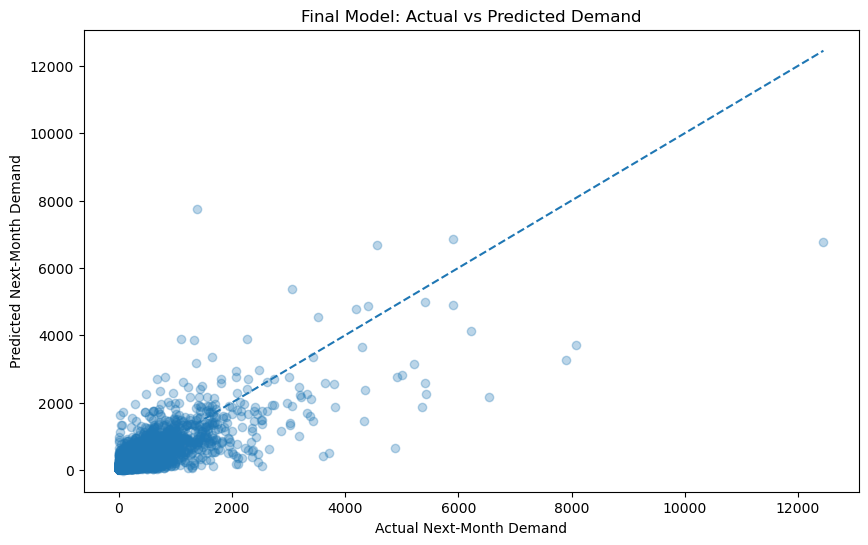

In [114]:
plt.figure(figsize=(10, 6))

plt.scatter(
    final_evaluation["Actual"],
    final_evaluation["Predicted"],
    alpha=0.3
)

max_value = max(
    final_evaluation["Actual"].max(),
    final_evaluation["Predicted"].max()
)

plt.plot(
    [0, max_value],
    [0, max_value],
    linestyle="--"
)

plt.xlabel("Actual Next-Month Demand")
plt.ylabel("Predicted Next-Month Demand")
plt.title("Final Model: Actual vs Predicted Demand")

plt.show()

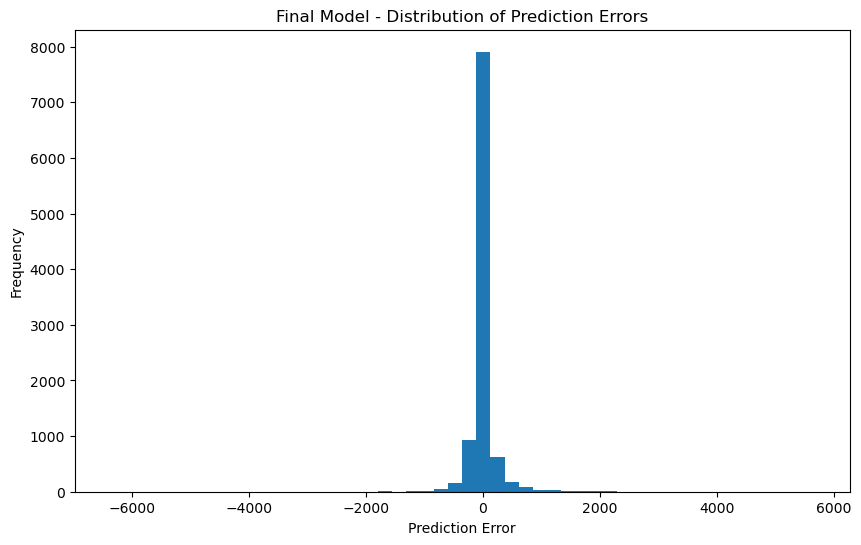

In [115]:
plt.figure(figsize=(10, 6))

plt.hist(
    final_evaluation["Error"],
    bins=50
)

plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Final Model - Distribution of Prediction Errors")

plt.show()

In [116]:
import joblib
import os

In [117]:
os.makedirs("../models", exist_ok=True)

In [118]:
gb_corrected

GradientBoostingRegressor(learning_rate=0.05, max_depth=5, min_samples_leaf=5,
                          random_state=42)

In [119]:
joblib.dump(
    gb_corrected,
    "../models/gradient_boosting_demand_model.pkl"
)

print("Model saved successfully.")

Model saved successfully.


In [120]:
joblib.dump(
    corrected_features,
    "../models/model_features.pkl"
)

print("Feature list saved successfully.")

Feature list saved successfully.


In [121]:
final_metrics = {
    "Model": "Gradient Boosting - Corrected",
    "MAE": final_mae,
    "RMSE": final_rmse
}

joblib.dump(
    final_metrics,
    "../models/model_metrics.pkl"
)

print(final_metrics)

{'Model': 'Gradient Boosting - Corrected', 'MAE': 108.56746604496233, 'RMSE': np.float64(265.048677150999)}


In [123]:
monthly_demand.to_csv(
    "../data/processed/monthly_demand_complete.csv",
    index=False
)

print("Monthly demand dataset saved successfully.")

Monthly demand dataset saved successfully.
